### 5.5.1 checking normality visually


In [23]:
import numpy as np
from scipy import stats
from scipy.stats import norm
import matplotlib.pyplot as plt 
import pandas as pd
import seaborn as sns
from pathlib import Path

In [24]:
#1. load the festival dataset
project_root = Path.cwd().parents[0]
fname = project_root / "datasets" / "DownloadFestival.dat"

# verify the path
# print(fname)

festival_data = pd.read_csv(fname, sep=r"\s+")
festival_data.info()
festival_data.describe()

<class 'pandas.DataFrame'>
RangeIndex: 810 entries, 0 to 809
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ticknumb  810 non-null    int64  
 1   gender    810 non-null    str    
 2   day1      810 non-null    float64
 3   day2      264 non-null    float64
 4   day3      123 non-null    float64
dtypes: float64(3), int64(1), str(1)
memory usage: 31.8 KB


,ticknumb,day1,day2,day3
count,810.000000,810.000000,264.000000,123.000000
mean,3616.212346,1.771136,0.960909,0.976504
std,610.241493,0.693539,0.720780,0.710277
min,2111.000000,0.020000,0.000000,0.020000
25%,3096.250000,1.312500,0.410000,0.440000
50%,3620.500000,1.790000,0.790000,0.760000
75%,4154.750000,2.230000,1.350000,1.525000
max,4765.000000,3.690000,3.440000,3.410000


In [39]:
# define the plotting function
def plot_hist_normal(
        data: pd.DataFrame, 
        column:str, 
        title: str | None = None, 
        bins: int = 25) -> None:
    """Plot a histogram, observed density, and fitted normal distribution"""
    values = data[column].dropna()
    median = values.median()
    mean = values.mean()
    std = values.std()
    n = values.size

    fig, ax = plt.subplots(figsize=(9, 6))

    # Histogram
    sns.histplot(
        data=values,
        bins=bins,
        stat="density",
        color="skyblue",
        edgecolor="white",
        alpha=0.5,
        ax=ax
    )

    sns.kdeplot(
        data=values,
        color="darkblue",
        linewidth=2,
        label="Observed Density",
        ax=ax
    )

    x = np.linspace(start=values.min(), stop=values.max(), num=500)
    ax.plot( # plot theoretical normal density against x
        x,
        norm.pdf(x=x, loc=mean, scale=std),
        color="red",
        linestyle="--",
        linewidth=1,
        label="Theoretical normal"
    )

    ax.set(
        title=title,
        xlabel=column,
        ylabel="Density"
    )

    ax.legend()

    ax.text(
        0.02,
        0.98,
        f"Mean = {mean:.2f}\n"
        f"Median = {median:.2f}\n"
        f"SD = {std:.2f}\n"
        f"N = {n}",
        transform=ax.transAxes,
        va="top",
    )



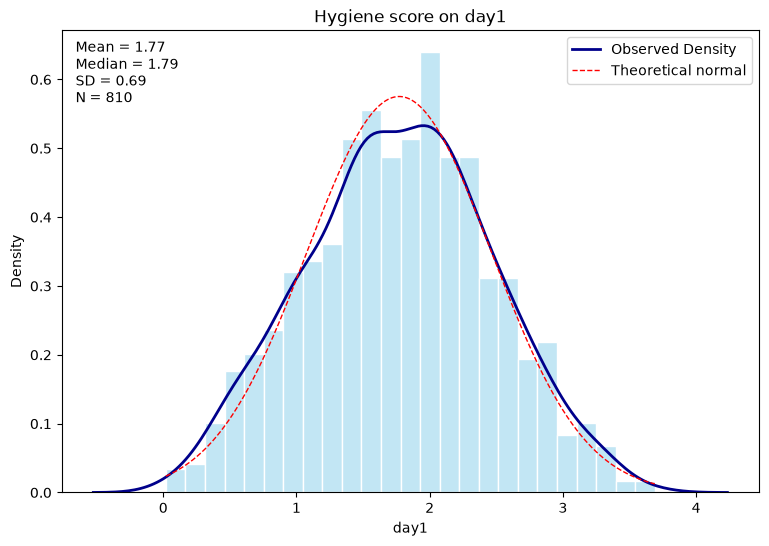

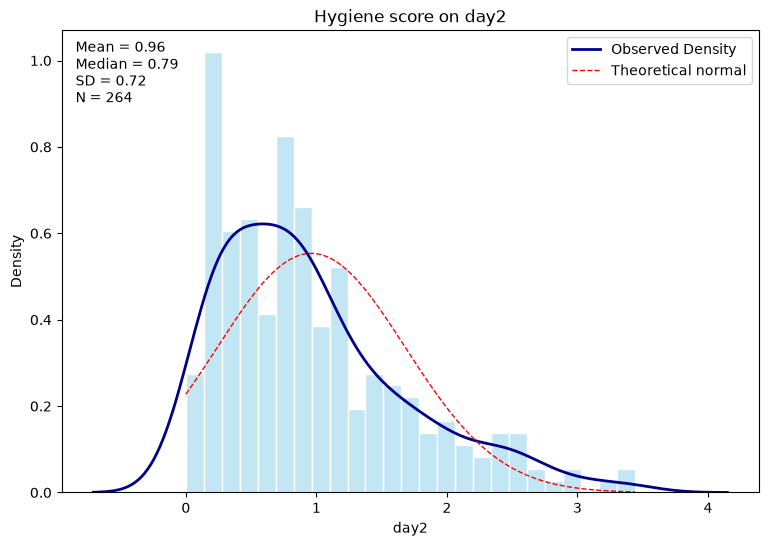

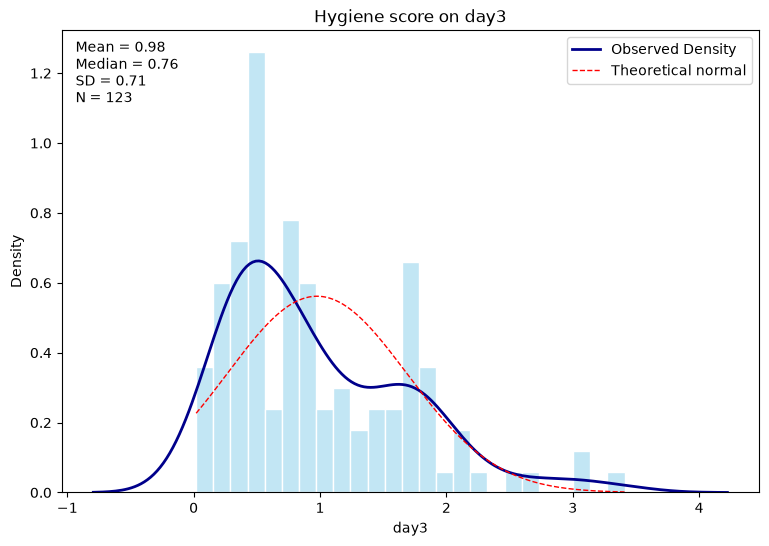

In [40]:
for day in ("day1", "day2", "day3"):
     plot_hist_normal(data = festival_data, column=day, title=f"Hygiene score on {day}")